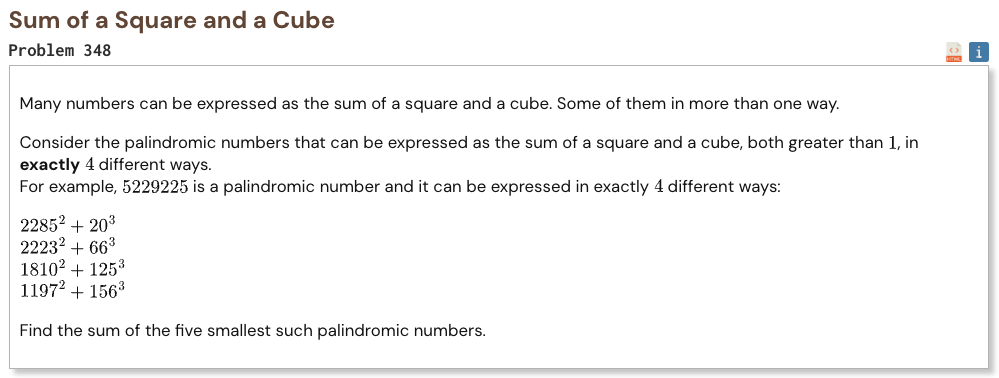

## Initial approach

* generate palindromic numbers in increasing order
* for each palindrome, test how many square plus cube representations it has
* both square and cube parts must be greater than one
* stop counting once a number has more than four representations
* collect palindromes with exactly four representations
* stop when the first five are found
* add those five palindromes

In [1]:
import math

def make_palindrome(prefix, odd_length):
    s = str(prefix)

    if odd_length:
        return int(s + s[-2::-1])

    return int(s + s[::-1])

def count_representations(n):
    count = 0
    max_cube_root = int(round(n ** (1 / 3))) + 2

    for a in range(2, max_cube_root + 1):
        cube = a ** 3

        if cube >= n:
            break

        square = n - cube
        root = math.isqrt(square)

        if root > 1 and root * root == square:
            count += 1

            if count > 4:
                break

    return count

def solve():
    found = []
    length = 1

    while len(found) < 5:
        half_len = (length + 1) // 2
        start = 1 if half_len == 1 else 10 ** (half_len - 1)
        end = 10 ** half_len

        for prefix in range(start, end):
            value = make_palindrome(prefix, length % 2 == 1)

            if count_representations(value) == 4:
                found.append(value)

                if len(found) == 5:
                    return sum(found)

        length += 1

In [2]:
%%time
result = solve()
print("Result:", result)

Result: 1004195061
CPU times: user 6.48 s, sys: 25.7 ms, total: 6.51 s
Wall time: 6.52 s
